# 💰 Score métier — coût FN vs FP

Dans un modèle de scoring crédit, **toutes les erreurs ne se valent pas**.
Ce notebook construit, justifie et visualise notre fonction de score métier.

**Plan**

1. Pourquoi un score métier custom ?
2. Le coût des erreurs en credit scoring
3. Choix du ratio FN:FP
4. Implémentation : `business_cost` et `business_gain`
5. Visualisation : matrice de coûts
6. Le seuil de décision optimal
7. Intégration avec scikit-learn (GridSearchCV)
8. Synthèse

## 1. Pourquoi un score métier custom ?

Les métriques classiques (accuracy, F1, AUC) traitent toutes les erreurs
de la même manière. C'est inadapté au crédit :

| Erreur | Effet métier | Coût (banque) |
|--------|--------------|---------------|
| **FN** (False Negative) | On a accordé le crédit à un futur défaut → on perd le capital | Élevé |
| **FP** (False Positive) | On refuse un bon client → on perd un manque à gagner sur les intérêts | Modéré |

Pour le crédit à la consommation, la littérature et la pratique
bancaire (Bâle II/III) convergent sur un ratio FN/FP de l'ordre de
**5:1** : un faux négatif coûte environ cinq fois plus cher qu'un
faux positif.

## 2. ⚙️ Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
FIG_DIR = ROOT / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

from scoring.business_score import (
    business_cost, business_gain, make_business_scorer,
    find_optimal_threshold, DEFAULT_FN_COST, DEFAULT_FP_COST,
)
print(f'DEFAULT_FN_COST = {DEFAULT_FN_COST}')
print(f'DEFAULT_FP_COST = {DEFAULT_FP_COST}')
print(f'Ratio default   = {DEFAULT_FN_COST / DEFAULT_FP_COST:.0f}:1')

DEFAULT_FN_COST = 5.0
DEFAULT_FP_COST = 1.0
Ratio default   = 5:1


## 3. La matrice des coûts

Pour 4 issues possibles dans une classification binaire :

In [2]:
cost_matrix = pd.DataFrame(
    [[0, 1], [5, 0]],
    index=['Réalité : non-défaut (0)', 'Réalité : défaut (1)'],
    columns=['Prédit : non-défaut (0)', 'Prédit : défaut (1)'],
)
print('Matrice des coûts (ratio 5:1)')
print()
cost_matrix

Matrice des coûts (ratio 5:1)



,Prédit : non-défaut (0),Prédit : défaut (1)
Réalité : non-défaut (0),0,1
Réalité : défaut (1),5,0


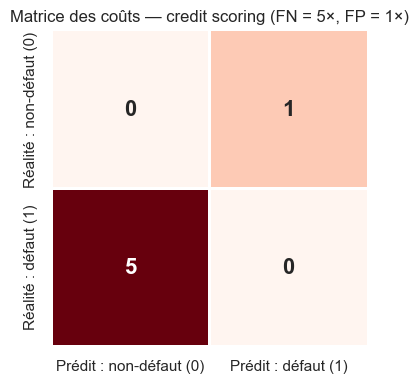

In [3]:
plt.figure(figsize=(7, 4))
sns.heatmap(cost_matrix, annot=True, fmt='d', cmap='Reds', cbar=False,
            linewidths=2, linecolor='white', square=True,
            annot_kws={'fontsize': 16, 'weight': 'bold'})
plt.title('Matrice des coûts — credit scoring (FN = 5×, FP = 1×)',
          fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / '15_cost_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Exemples concrets — comment on calcule

Trois scénarios sur 10 clients (3 défauts réels, 7 non-défauts) :

In [4]:
def scenario(name, y_true, y_pred):
    cost = business_cost(y_true, y_pred)
    gain = business_gain(y_true, y_pred)
    tn = sum((np.array(y_true) == 0) & (np.array(y_pred) == 0))
    fp = sum((np.array(y_true) == 0) & (np.array(y_pred) == 1))
    fn = sum((np.array(y_true) == 1) & (np.array(y_pred) == 0))
    tp = sum((np.array(y_true) == 1) & (np.array(y_pred) == 1))
    print(f'─── {name} ───')
    print(f'  y_true : {y_true}')
    print(f'  y_pred : {y_pred}')
    print(f'  TN={tn}, FP={fp}, FN={fn}, TP={tp}')
    print(f'  cost   = {fp}*1 + {fn}*5 = {cost:.0f}')
    print(f'  gain   = {gain:.3f}\n')


y_true = [0,0,0,0,0,0,0, 1,1,1]

# Scénario A : modèle parfait
scenario('A — Modèle parfait', y_true, [0,0,0,0,0,0,0, 1,1,1])

# Scénario B : modèle "rate tout" (prédit toujours 0)
scenario('B — Toujours non-défaut', y_true, [0,0,0,0,0,0,0, 0,0,0])

# Scénario C : modèle "trop prudent" (prédit toujours 1)
scenario('C — Toujours défaut', y_true, [1,1,1,1,1,1,1, 1,1,1])

# Scénario D : modèle réaliste (2 FP, 1 FN)
scenario('D — Réaliste', y_true, [1,0,0,0,1,0,0, 1,1,0])

─── A — Modèle parfait ───
  y_true : [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
  y_pred : [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
  TN=7, FP=0, FN=0, TP=3
  cost   = 0*1 + 0*5 = 0
  gain   = 1.000

─── B — Toujours non-défaut ───
  y_true : [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
  y_pred : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  TN=7, FP=0, FN=3, TP=0
  cost   = 0*1 + 3*5 = 15
  gain   = 0.000

─── C — Toujours défaut ───
  y_true : [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
  y_pred : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  TN=0, FP=7, FN=0, TP=3
  cost   = 7*1 + 0*5 = 7
  gain   = 0.533

─── D — Réaliste ───
  y_true : [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
  y_pred : [1, 0, 0, 0, 1, 0, 0, 1, 1, 0]
  TN=5, FP=2, FN=1, TP=2
  cost   = 2*1 + 1*5 = 7
  gain   = 0.533



**Lecture des scénarios :**

- **Le modèle "toujours non-défaut" est PIRE que le modèle "toujours défaut"** (15 vs 7) parce qu'il rate les 3 défauts (3 × 5 = 15) tandis que l'autre fait 7 FP (7 × 1 = 7). Avec un ratio 5:1, **il vaut mieux trop prédire le défaut que pas assez**.
- Le modèle réaliste (D) a un gain de 0.467 — meilleur que B (0.0) mais pas parfait.

## 5. Le seuil de décision optimal

Quand un modèle prédit une **probabilité** (par ex. 0.32), on doit choisir
un **seuil** pour décider entre "défaut" et "non-défaut".

- Seuil = 0.5 (par défaut) → optimal pour l'**accuracy**
- Seuil < 0.5 → on capture plus de défauts (moins de FN, plus de FP) → meilleur pour notre score métier avec ratio asymétrique

On simule sur un modèle artificiel.

In [5]:
# Simulation : 1000 clients, 25% défaut
rng = np.random.default_rng(42)
n = 1000
y_true = rng.binomial(1, 0.25, size=n)

# Proba bruitée mais informative (mimique un vrai modèle)
y_proba = np.clip(
    y_true * 0.45 + rng.normal(0.25, 0.18, size=n),
    0, 1
)

print(f'Distribution des probas par classe :')
print(f'  Classe 0 : mean={y_proba[y_true == 0].mean():.3f}, '
      f'std={y_proba[y_true == 0].std():.3f}')
print(f'  Classe 1 : mean={y_proba[y_true == 1].mean():.3f}, '
      f'std={y_proba[y_true == 1].std():.3f}')

Distribution des probas par classe :
  Classe 0 : mean=0.242, std=0.169
  Classe 1 : mean=0.694, std=0.170


In [6]:
result = find_optimal_threshold(y_true, y_proba, fn_cost=5, fp_cost=1)
print(f'Seuil optimal trouvé : {result.best_threshold:.2f}')
print(f'Coût correspondant   : {result.best_cost:.0f}')
print(f'Gain correspondant   : {result.best_gain:.3f}')

# Comparons avec seuil = 0.5
default_pred = (y_proba >= 0.5).astype(int)
default_cost = business_cost(y_true, default_pred)
default_gain = business_gain(y_true, default_pred)
print()
print(f'À seuil 0.5 (accuracy)  : cost={default_cost:.0f}, gain={default_gain:.3f}')
print(f'À seuil optimal métier  : cost={result.best_cost:.0f}, gain={result.best_gain:.3f}')
print(f'Amélioration            : -{(default_cost - result.best_cost):.0f} de coût')

Seuil optimal trouvé : 0.44
Coût correspondant   : 183
Gain correspondant   : 0.858

À seuil 0.5 (accuracy)  : cost=235, gain=0.817
À seuil optimal métier  : cost=183, gain=0.858
Amélioration            : -52 de coût


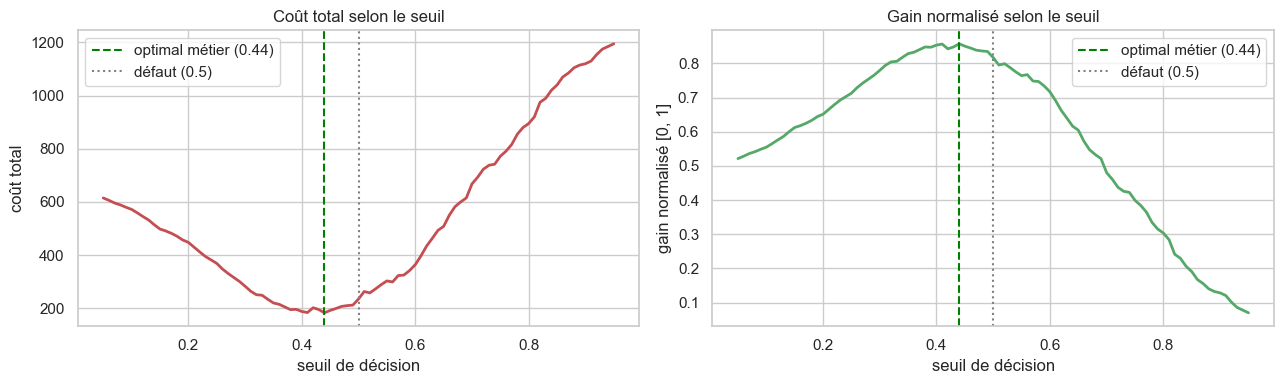

In [7]:
# Courbe coût/gain en fonction du seuil
df_t = pd.DataFrame(result.all_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_t['threshold'], df_t['cost'], lw=2, color='#C44E52')
axes[0].axvline(result.best_threshold, color='green', ls='--',
                label=f'optimal métier ({result.best_threshold:.2f})')
axes[0].axvline(0.5, color='gray', ls=':', label='défaut (0.5)')
axes[0].set_xlabel('seuil de décision')
axes[0].set_ylabel('coût total')
axes[0].set_title('Coût total selon le seuil')
axes[0].legend()

axes[1].plot(df_t['threshold'], df_t['gain'], lw=2, color='#55A868')
axes[1].axvline(result.best_threshold, color='green', ls='--',
                label=f'optimal métier ({result.best_threshold:.2f})')
axes[1].axvline(0.5, color='gray', ls=':', label='défaut (0.5)')
axes[1].set_xlabel('seuil de décision')
axes[1].set_ylabel('gain normalisé [0, 1]')
axes[1].set_title('Gain normalisé selon le seuil')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '16_threshold_optimization.png', dpi=120, bbox_inches='tight')
plt.show()

**Lecture** : le seuil optimal métier est plus bas que 0.5. Le modèle
est encouragé à classer plus de clients en "défaut potentiel" parce que
chaque FN évité économise 5× le coût d'un FP supplémentaire.

## 6. Effet du ratio FN:FP sur le seuil optimal

Plus on pénalise les FN, plus le seuil descend (le modèle devient
"paranoïaque" et accepte plus de FP pour éviter les FN).

In [8]:
ratios = [(1, 1), (2, 1), (5, 1), (10, 1), (20, 1)]
records = []
for fn, fp in ratios:
    r = find_optimal_threshold(y_true, y_proba, fn_cost=fn, fp_cost=fp)
    records.append({
        'fn_cost': fn, 'fp_cost': fp,
        'ratio': f'{fn}:{fp}',
        'best_threshold': r.best_threshold,
        'best_cost': r.best_cost,
        'best_gain': r.best_gain,
    })

ratios_df = pd.DataFrame(records)
ratios_df

,fn_cost,fp_cost,ratio,best_threshold,best_cost,best_gain
0,1,1,1:1,0.56,83.0,0.888291
1,2,1,2:1,0.49,119.0,0.839838
2,5,1,5:1,0.44,183.0,0.857588
3,10,1,10:1,0.38,235.0,0.908560
4,20,1,20:1,0.31,309.0,0.939883


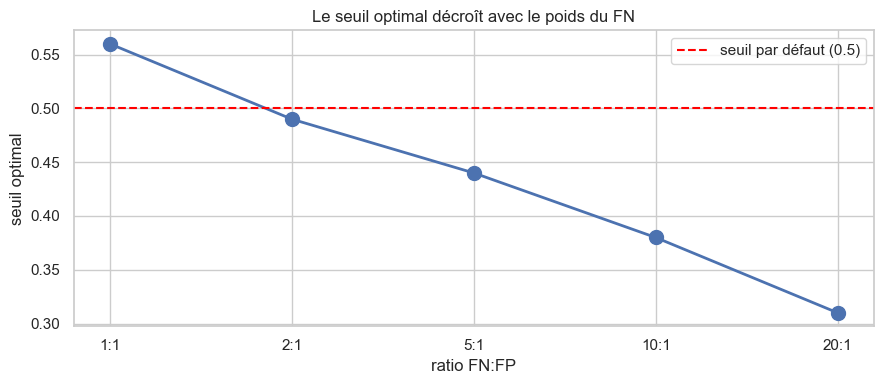

In [9]:
plt.figure(figsize=(9, 4))
plt.plot([r['ratio'] for r in records],
         [r['best_threshold'] for r in records],
         marker='o', lw=2, markersize=10, color='#4C72B0')
plt.axhline(0.5, color='red', ls='--', label='seuil par défaut (0.5)')
plt.xlabel('ratio FN:FP')
plt.ylabel('seuil optimal')
plt.title('Le seuil optimal décroît avec le poids du FN')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '17_threshold_vs_ratio.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Intégration avec scikit-learn

Pour utiliser le business score dans `GridSearchCV` ou `cross_val_score`,
on enveloppe `business_gain` dans un `make_scorer` :

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# Mini dataset synthétique
X, y = make_classification(n_samples=500, n_features=10, n_classes=2,
                           weights=[0.78, 0.22], random_state=42)

scorer = make_business_scorer(fn_cost=5, fp_cost=1)
clf = LogisticRegression(max_iter=1000, class_weight='balanced')

cv_scores = cross_val_score(clf, X, y, cv=5, scoring=scorer)
print(f'CV business_gain (LogReg) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'Scores individuels        : {cv_scores.round(3)}')

CV business_gain (LogReg) : 0.762 ± 0.033
Scores individuels        : [0.748 0.791 0.8   0.709 0.764]


## 8. 📌 Synthèse

### Le score métier en deux fonctions

| Fonction | Sens | À minimiser ou maximiser |
|----------|------|---------------------------|
| `business_cost` | Coût total (sans unité ou en NT$ si on multiplie par les vrais coûts) | **Minimiser** |
| `business_gain` | Score normalisé `[0, 1]` | **Maximiser** |

### Le ratio 5:1 par défaut

- Justifié par la pratique bancaire (Bâle II/III)
- Paramétrable via les arguments `fn_cost` et `fp_cost`
- Avec ce ratio, le seuil de décision optimal est **toujours inférieur à 0.5**

### Réutilisation

```python
from scoring.business_score import (
    business_gain, make_business_scorer, find_optimal_threshold,
)

# Métrique d'évaluation
score = business_gain(y_test, y_pred)

# Scorer pour GridSearchCV
scorer = make_business_scorer(fn_cost=5, fp_cost=1)
grid = GridSearchCV(model, params, scoring=scorer, cv=5)

# Seuil optimal après entraînement
result = find_optimal_threshold(y_val, model.predict_proba(X_val)[:, 1])
optimal_threshold = result.best_threshold
```

### Prochaine étape

→ Étape 4 de l'examen : **entraîner et comparer** LogReg, RandomForest
et XGBoost avec GridSearchCV, SMOTE et SHAP, en optimisant sur ce
score métier.